# Module 2 · Millisecond Operational Analytics

**Story:** leadership, Treasury, and Finance need transaction volumes,
pending statuses, and net liquidity in seconds, not hours. This notebook
loads a large synthetic money-movement dataset and runs the exact kind of
aggregation pipeline a leadership dashboard would run against it — timed,
live, on real (synthetic) data. Expect low hundreds of milliseconds
end-to-end (including the network round trip to Atlas from wherever you're
running this) once the query is properly indexed and scoped to a realistic
window — the honest comparison isn't "milliseconds vs. instant," it's
"a fraction of a second vs. hours."

**On dashboarding tools:** the original plan called for Atlas Charts. This
version deliberately skips it — Charts is fine for a quick single chart but
gets awkward fast for anything with cross-filtering or multiple linked
panels. Two better options depending on what you're building:

1. **This notebook** — the pipeline + chart shown here, running natively
   against MongoDB. Good for "leadership wants this specific view" work.
2. **Grafana**, which is the pattern most shops already run. Two flavors:
   - *Infra/ops metrics* (replication lag, opcounters, connections) via
     `mongodb_exporter` → Prometheus → Grafana — fully open source, zero
     licensing friction. See `ops-dashboard/` in this repo; that's what
     Module 1's failover demo pairs with.
   - *Business data* (the histograms/liquidity queries below, live in
     Grafana) needs a MongoDB data source plugin. Grafana Labs ships an
     official one, but it's **Grafana Enterprise / Cloud Pro+ only** — worth
     knowing before you commit to that path for a production dashboard. Free
     community MongoDB plugins exist but are unsigned and less
     battle-tested; fine for a demo, not something to bet a leadership
     dashboard on without vetting.


In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pymongo[encryption]", "certifi", "python-dotenv", "requests"],
        check=True,
    )
    from getpass import getpass
    ATLAS_URI = os.environ.get("ATLAS_URI") or getpass("Atlas connection string (ATLAS_URI): ")
else:
    from dotenv import load_dotenv
    load_dotenv()
    ATLAS_URI = os.environ["ATLAS_URI"]

DEMO_DB = os.environ.get("DEMO_DB", "amex_demo")
import certifi
CA_FILE = certifi.where()
print("Environment:", "Colab" if IN_COLAB else "local", "| DB:", DEMO_DB)

from pymongo import MongoClient

client = MongoClient(ATLAS_URI, tlsCAFile=CA_FILE)
db = client[DEMO_DB]
coll = db.money_movement


Environment: local | DB: amex_demo


## Generate a large money-movement dataset

Defaults to 200,000 documents — enough to make the "fast queries at scale"
point without a multi-minute load in a live demo. Set `TRANSACTION_COUNT` in
`.env` (or before running in Colab) to go bigger; this scales the same way
to the several-million-row datasets a real AMEX workload would have.


In [2]:
import random
import time
from datetime import datetime, timedelta, timezone

random.seed(7)

N = int(os.environ.get("TRANSACTION_COUNT", "200000"))
TYPES = ["wire", "ach", "bill_pay", "internal_transfer"]
STATUSES = ["Executed", "Pending", "Accepted"]
STATUS_WEIGHTS = [80, 12, 8]
PENDING_REASONS = ["compliance_review", "insufficient_funds_hold", "recipient_verification", "manual_review"]

def make_transfer(i):
    status = random.choices(STATUSES, weights=STATUS_WEIGHTS)[0]
    created = datetime.now(timezone.utc) - timedelta(
        days=random.randint(0, 29), hours=random.randint(0, 23), minutes=random.randint(0, 59)
    )
    doc = {
        "transfer_id": f"MM{i:09d}",
        "type": random.choice(TYPES),
        "status": status,
        "direction": random.choice(["incoming", "outgoing"]),
        "amount": round(random.uniform(25, 50000), 2),
        "created_at": created,
    }
    if status == "Pending":
        doc["pending_reason"] = random.choice(PENDING_REASONS)
    return doc

print(f"Generating {N:,} money-movement documents...")
t0 = time.perf_counter()

db.money_movement.drop()
BATCH = 20000
batch = []
for i in range(N):
    batch.append(make_transfer(i))
    if len(batch) == BATCH:
        coll.insert_many(batch, ordered=False)
        batch = []
if batch:
    coll.insert_many(batch, ordered=False)

# Index supporting the date+status aggregation below — this is what keeps
# the aggregation fast at scale, not just on a small demo dataset.
coll.create_index([("created_at", 1), ("status", 1)])

print(f"Loaded {coll.count_documents({}):,} docs in {time.perf_counter() - t0:.1f}s")


Generating 200,000 money-movement documents...


Loaded 200,000 docs in 19.6s


## Fast aggregation: daily volume by status

The query leadership actually wants: "how many transfers per day, broken
down by status, over the last week." Scoped to a recent window and backed
by the `(created_at, status)` index created above — this is how a real
dashboard would query it (nobody re-aggregates full history on every
refresh), and it's the difference between an index-backed query and a full
collection scan.


In [3]:
import pandas as pd

since = datetime.now(timezone.utc) - timedelta(days=7)
pipeline = [
    {"$match": {"created_at": {"$gte": since}}},
    {"$group": {
        "_id": {
            "date": {"$dateToString": {"format": "%Y-%m-%d", "date": "$created_at"}},
            "status": "$status",
        },
        "count": {"$sum": 1},
        "total_amount": {"$sum": "$amount"},
    }},
    {"$sort": {"_id.date": 1}},
]

start = time.perf_counter()
rows = list(coll.aggregate(pipeline))
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Aggregated {len(rows)} date/status buckets from the last 7 days in {elapsed_ms:.0f} ms")
print("(That's wall-clock time including a full network round trip to Atlas —")
print(" compare to the hours this takes today pulled by hand.)")

df = pd.DataFrame([
    {"date": r["_id"]["date"], "status": r["_id"]["status"], "count": r["count"], "total_amount": r["total_amount"]}
    for r in rows
])
pivot = df.pivot_table(index="date", columns="status", values="count", fill_value=0)
pivot


Aggregated 24 date/status buckets from the last 7 days in 373 ms
(That's wall-clock time including a full network round trip to Atlas —
 compare to the hours this takes today pulled by hand.)


status,Accepted,Executed,Pending
date,,,
2026-08-12,1.0,6.0,2.0
2026-08-13,497.0,5223.0,825.0
2026-08-14,555.0,5363.0,832.0
2026-08-15,555.0,5457.0,781.0
2026-08-16,532.0,5284.0,770.0
2026-08-17,542.0,5453.0,800.0
2026-08-18,539.0,5295.0,791.0
2026-08-19,515.0,5369.0,838.0


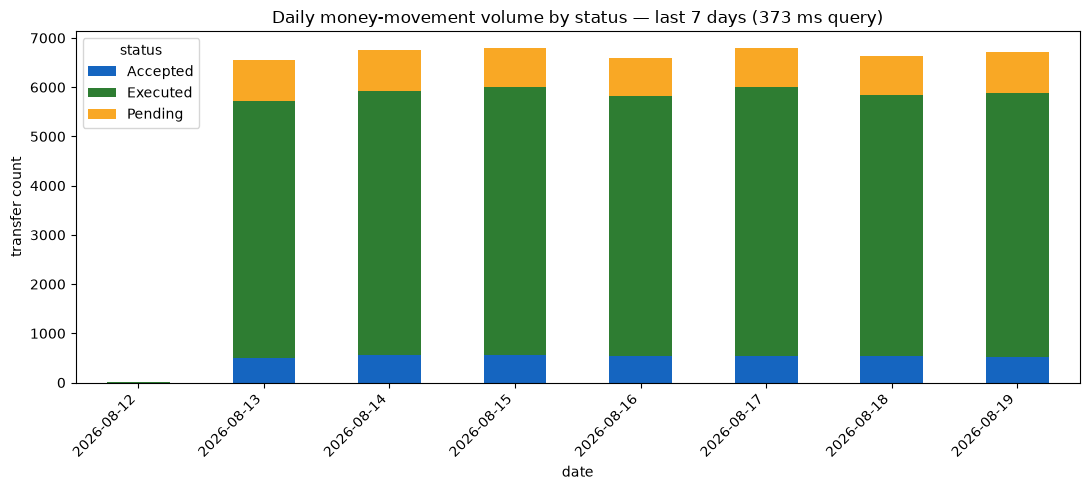

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", stacked=True, ax=ax,
           color={"Executed": "#2e7d32", "Pending": "#f9a825", "Accepted": "#1565c0"})
ax.set_ylabel("transfer count")
ax.set_title(f"Daily money-movement volume by status — last 7 days ({elapsed_ms:.0f} ms query)")
ax.legend(title="status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Treasury liquidity: net incoming vs. outgoing (executed only)

The other query Treasury/Finance actually run manually today — takes hours
by their account, well under a second here. This one scans every executed
record ever written (a genuine full-history rollup, not a windowed query),
so it's a fair "worst case" comparison.


In [5]:
liquidity_pipeline = [
    {"$match": {"status": "Executed"}},
    {"$group": {"_id": "$direction", "total": {"$sum": "$amount"}, "count": {"$sum": 1}}},
]

start = time.perf_counter()
liquidity = {r["_id"]: r for r in coll.aggregate(liquidity_pipeline)}
elapsed_ms = (time.perf_counter() - start) * 1000

incoming = liquidity.get("incoming", {}).get("total", 0)
outgoing = liquidity.get("outgoing", {}).get("total", 0)
net = incoming - outgoing

print(f"Query time: {elapsed_ms:.1f} ms")
print(f"Incoming (executed): ${incoming:,.2f}")
print(f"Outgoing (executed): ${outgoing:,.2f}")
print(f"Net liquidity:       ${net:,.2f}")


Query time: 591.4 ms
Incoming (executed): $2,006,747,796.98
Outgoing (executed): $1,996,966,037.86
Net liquidity:       $9,781,759.12


### Presenter talking points

- Both queries ran in well under a second (hundreds of ms, including a full
  network round trip to Atlas) against a 200k-row — or however large you set
  `TRANSACTION_COUNT` — collection. The gap this closes is "hours to pull
  transaction counts and histograms" from the current pain-point list; it's
  not literally instantaneous, and that honest framing holds up better under
  follow-up questions than an overclaimed "milliseconds" would.
- The index created during setup is doing the real work here — same
  Performance-Advisor-driven indexing story as Module 3, just applied to an
  analytics workload instead of a lookup query.
- This pattern — pipeline in, pandas/plot out — is exactly what would sit
  behind a leadership-facing internal tool or a Grafana panel (via the
  MongoDB data source, see the note above on licensing) if AMEX wants a
  persistent dashboard rather than an on-demand notebook.
